# Install

In [ ]:
!pip install pandas numpy scikit-learn Sastrawi nltk wordcloud matplotlib seaborn evaluate transformers iterative-stratification torch -q

# Library

In [ ]:
import re
import string
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import requests
import csv
from io import StringIO
from collections import Counter
from transformers import pipeline
from tqdm import tqdm
from wordcloud import WordCloud, STOPWORDS

import torch
import torch.nn as nn
import pickle
import json
import evaluate

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import DataCollatorWithPadding
from sklearn.preprocessing import MultiLabelBinarizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.metrics import f1_score, accuracy_score, classification_report, multilabel_confusion_matrix

# Laoding Dataset

In [ ]:
df = pd.read_csv("komentar_mbg.csv")

df

# Assesing Dataset

In [ ]:
df.info()

# Pelabelan

In [ ]:
sentiment_classifier = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier",
    device=0
)

emotion_classifier = pipeline(
    "sentiment-analysis",
    model="StevenLimcorn/indonesian-roberta-base-emotion-classifier",
    device=0
)

tqdm.pandas()

# Labeling Intensitas
def get_intensity(text):
    text_str = str(text)
    text_lower = text_str.lower()

    kata_penegas = [
        'banget', 'sekali', 'parah', 'sangat', 'beneran', 'bgt', 'ancur', 'hancur',
        'gila', 'keterlaluan', 'nyesel', 'idiot', 'bancakan', 'kroni', 'penipu',
        'tipu', 'goblok', 'bodoh', 'bullshit', 'mencekik', 'waspada', 'bohong'
    ]

    has_penegas = any(kata in text_lower.split() for kata in kata_penegas)
    has_shouting = text_str.isupper() and len(text_str) > 10
    has_strong_punct = bool(re.search(r'[!?]{2,}', text_str))

    if has_penegas or has_shouting or has_strong_punct:
        return "Tinggi"

    kata_sifat = [
        'bagus', 'kecewa', 'lumayan', 'baik', 'jelek', 'keren', 'suka', 'puas',
        'sedih', 'marah', 'takut', 'senang', 'kurang', 'cukup', 'setuju', 'mantap'
    ]
    has_sifat = any(kata in text_lower.split() for kata in kata_sifat)

    if has_sifat:
        return "Sedang"

    return "Rendah"

# Labeling Aspek
aspek_keywords = {
    'Anggaran': [
        'uang', 'uangnya', 'dana', 'dananya', 'biaya', 'biayanya', 'apbn', 'apbd',
        'anggaran', 'anggarannya', 'pajak', 'triliun', 'miliar', 'juta', 'duit', 'duitnya',
        'korup', 'korupsi', 'dikorupsi', 'bancakan', 'markup', 'rugi', 'merugi',
        'mahal', 'bocor', 'kebocoran', 'tilep', 'ditilep', 'sunat', 'disunat',
        'inflasi', 'hutang', 'utang', 'ekonomi', 'boros', 'pemborosan'
    ],
    'Kualitas Makanan': [
        'menu', 'menunya', 'porsi', 'porsinya', 'ikan', 'nasi', 'sapi', 'lauk', 'sayur',
        'telur', 'susu', 'ayam', 'daging', 'tempe', 'tahu', 'makanan', 'makanannya',
        'minuman', 'gizi', 'gizinya', 'nutrisi', 'vitamin', 'karbo', 'protein', 'kalori',
        'enak', 'hambar', 'basi', 'higienis', 'bersih', 'kotor', 'rasa', 'rasanya',
        'kenyang', 'instan', 'micin', 'msg', 'keracunan', 'dapur', 'masak', 'dimasak', 'kualitas'
    ],
    'Program': [
        'program_mbg', 'mbg', 'program', 'programnya', 'kebijakan', 'simulasi',
        'uji coba', 'implementasi', 'kelola', 'dikelola', 'rencana', 'aturan',
        'nasional', 'proyek', 'tugas', 'agenda', 'janji', 'kampanye', 'launching',
        'perdana', 'wacana', 'pelaksanaan', 'berjalan'
    ],
    'Distribusi': [
        'sekolah', 'siswa', 'murid', 'anak', 'guru', 'desa', 'daerah', 'kota',
        'kabupaten', 'provinsi', 'sd', 'smp', 'sma', 'pelosok', 'terpencil',
        'merata', 'salur', 'disalurkan', 'menyalurkan', 'penyaluran', 'bagi',
        'dibagi', 'dibagikan', 'pembagian', 'sasaran', 'jangkau', 'terjangkau',
        'posyandu', 'logistik', 'kurir', 'antar', 'diantar'
    ],
    'Pemerintahan': [
        'pemerintah', 'prabowo', 'mahfud', 'gibran', 'jokowi', 'presiden', 'wapres',
        'dpr', 'partai', 'koalisi', 'kwalisi', 'negara', 'menteri', 'politik',
        'rezim', 'pejabat', 'aparat', 'tni', 'polri', 'pusat', 'pemda', 'birokrasi',
        'instansi', 'dinas'
    ]
}

kata_konteks = ['buruk', 'kurang', 'bagus', 'masalah', 'gagal', 'sukses', 'salah', 'benar', 'parah', 'mahal', 'murah']

aspek_patterns = {}
for aspek, keywords in aspek_keywords.items():
    aspek_patterns[aspek] = re.compile(r'\b(?:' + '|'.join(keywords) + r')\b')

def get_aspect(text):
    text_lower = str(text).lower()

    text_lower = re.sub(r'\bmakan(an)?\s+bergizi(\s+gratis)?\b', 'program_mbg', text_lower)
    text_lower = re.sub(r'\bmakan(\s+siang)?\s+gratis\b', 'program_mbg', text_lower)
    text_lower = text_lower.replace('mbg', 'program_mbg')

    scores = {aspek: 0 for aspek in aspek_keywords.keys()}

    for aspek, pattern in aspek_patterns.items():
        matches = list(pattern.finditer(text_lower))
        scores[aspek] += len(matches)

        for match in matches:
            start_idx = max(0, match.start() - 25)
            end_idx = min(len(text_lower), match.end() + 25)
            context_window = text_lower[start_idx:end_idx]

            if any(kntx in context_window for kntx in kata_konteks):
                scores[aspek] += 2

    detected_aspects = [aspek for aspek, skor in scores.items() if skor > 0]

    if not detected_aspects:
        return "Program"

    return ", ".join(detected_aspects)

# Labeling Process
def labeling(text):
    text_snippet = str(text)[:512]
    try:
        res_sent = sentiment_classifier(text_snippet)[0]
        sent_label = res_sent['label'].lower()
        mapping_sent = {'positive': 'positif', 'negative': 'negatif', 'neutral': 'netral'}
        final_sent = mapping_sent.get(sent_label, 'netral')

        res_emo = emotion_classifier(text_snippet)[0]
        emo_label = res_emo['label'].lower()
        mapping_emo = {
            'happy': 'Senang', 'love': 'Senang', 'anger': 'Marah',
            'fear': 'Cemas', 'sadness': 'Cemas'
        }
        if final_sent == 'netral' or res_emo['score'] < 0.4:
            final_emo = 'Netral'
        else:
            final_emo = mapping_emo.get(emo_label, 'Netral')

        final_intensity = get_intensity(text)
        final_aspect = get_aspect(text)

        return final_sent, final_emo, final_intensity, final_aspect, res_sent['score']

    except Exception:
        return None, None, None, None, 0

df = pd.read_csv("komentar_mbg.csv")
print("Memulai pelabelan")
results = df['cleaned_comment'].progress_apply(labeling)

df[['sentimen_global', 'emosi', 'intensitas', 'aspek', 'confidence']] = pd.DataFrame(results.tolist(), index=df.index)
df_clean = df.dropna(subset=['sentimen_global', 'emosi', 'aspek'])

print(df_clean['sentimen_global'].value_counts())
print(df_clean['emosi'].value_counts())
print(df_clean['intensitas'].value_counts())

df_clean.to_csv("data_komentar_mbg_labeled.xlsx", index=False)
print("\nProses selesai. File disimpan sebagai: data_komentar_mbg_labeled.xlsx")

# Sentimen Global

In [ ]:
df = pd.read_excel('data_komentar_mbg_labeled.xlsx')
df = df.dropna(subset=['cleaned_comment', 'sentimen_global'])

label_mapping = {'negatif': 0, 'netral': 1, 'positif': 2}
df['label'] = df['sentimen_global'].str.lower().str.strip().map(label_mapping)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['cleaned_comment'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42
)

print("Memuat Tokenizer...")
model_name = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(texts, labels):
    encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)
    dataset = Dataset.from_dict({
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask'],
        'labels': labels
    })
    return dataset

train_dataset = tokenize_function(train_texts, train_labels)
val_dataset = tokenize_function(val_texts, val_labels)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

print("Memuat Model IndoBERT...")
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(label_mapping))

training_args = TrainingArguments(
    output_dir='./results_sentimen_global',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("Mulai Fine-Tuning...")
trainer.train()

save_directory = "./model_indobert_sentimen_global"
print(f"Menyimpan model ke {save_directory}...")

model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

print("Proses selesai! Model berhasil disimpan.")

Memuat Tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Memuat Model IndoBERT...


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Menyimpan model ke ./model_indobert_sentimen_global...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Proses selesai! Model berhasil disimpan.



Menghasilkan prediksi untuk data validasi...



=== Classification Report ===
              precision    recall  f1-score   support

     negatif       0.84      0.78      0.81       143
      netral       0.79      0.73      0.76       129
     positif       0.74      0.87      0.80       128

    accuracy                           0.79       400
   macro avg       0.79      0.79      0.79       400
weighted avg       0.79      0.79      0.79       400


Menampilkan Confusion Matrix...


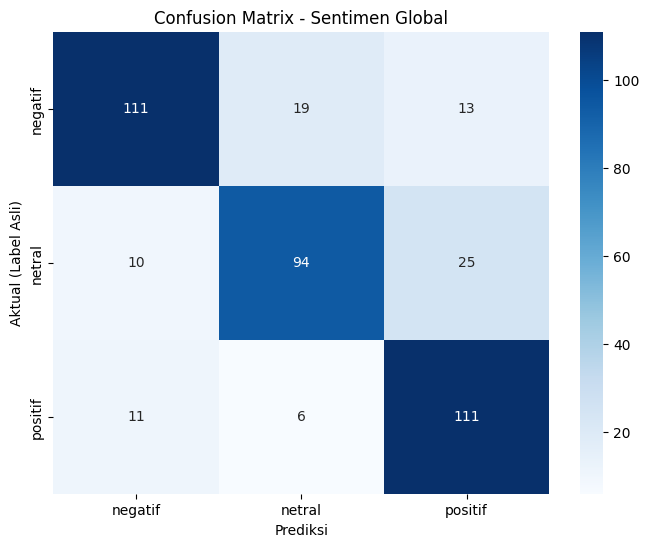

In [ ]:
print("\nMenghasilkan prediksi untuk data validasi...")
predictions = trainer.predict(val_dataset)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

target_names = ['negatif', 'netral', 'positif']

print("\n=== Classification Report ===")
report = classification_report(y_true, y_pred, target_names=target_names)
print(report)

print("\nMenampilkan Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Prediksi')
plt.ylabel('Aktual (Label Asli)')
plt.title('Confusion Matrix - Sentimen Global')
plt.show()

with open(f"{save_directory}/classification_report.txt", "w") as f:
    f.write(report)

# Emosi

In [ ]:
df = pd.read_excel('data_komentar_mbg_labeled.xlsx')
df = df.dropna(subset=['cleaned_comment', 'emosi'])

emotion_mapping = {'Marah': 0, 'Senang': 1, 'Cemas': 2, 'Netral': 3}
df['label'] = df['emosi'].map(emotion_mapping)

df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['cleaned_comment'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

model_name = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_func(texts, labels):
    encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)
    return Dataset.from_dict({**encodings, 'labels': labels})

train_ds = tokenize_func(train_texts, train_labels)
val_ds = tokenize_func(val_texts, val_labels)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(emotion_mapping))

training_args = TrainingArguments(
    output_dir='./results_indobert_emotion',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    learning_rate=3e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    weight_decay=0.01,
    metric_for_best_model="f1",
    logging_steps=10
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

print("Memulai Training Emosi...")
trainer.train()

model.save_pretrained("./model_indobert_emosi")
tokenizer.save_pretrained("./model_indobert_emosi")
print("Proses selesai dan model disimpan.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Memulai Training Emosi...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.641105,0.839652,0.667500,0.598263,0.700066,0.619625
2,0.358929,0.643201,0.777500,0.720404,0.732927,0.715903
3,0.242612,0.867915,0.755000,0.715174,0.721483,0.713558
4,0.116107,1.043729,0.767500,0.728592,0.741754,0.721502
5,0.056556,1.073116,0.782500,0.745526,0.760604,0.736722


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Proses selesai dan model disimpan.



Menghasilkan prediksi untuk data validasi...



=== Classification Report Emosi ===
              precision    recall  f1-score   support

       Marah       0.77      0.78      0.78        96
      Senang       0.81      0.85      0.83       111
       Cemas       0.67      0.50      0.57        44
      Netral       0.79      0.82      0.81       149

    accuracy                           0.78       400
   macro avg       0.76      0.74      0.75       400
weighted avg       0.78      0.78      0.78       400



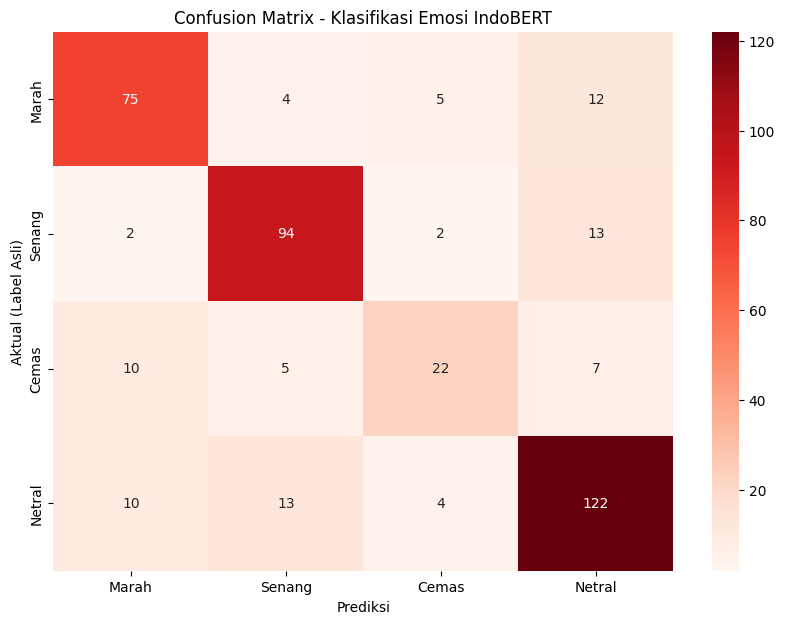

In [ ]:
print("\nMenghasilkan prediksi untuk data validasi...")
output = trainer.predict(val_ds)
y_pred = np.argmax(output.predictions, axis=-1)
y_true = output.label_ids

target_names = list(emotion_mapping.keys())

print("\n=== Classification Report Emosi ===")
print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Prediksi')
plt.ylabel('Aktual (Label Asli)')
plt.title('Confusion Matrix - Klasifikasi Emosi IndoBERT')
plt.show()

with open("./model_indobert_emosi/eval_emotion_report.txt", "w") as f:
    f.write("=== Classification Report Emosi ===\n")
    f.write(classification_report(y_true, y_pred, target_names=target_names))

# Intensitas

In [ ]:
df = pd.read_excel('data_komentar_mbg_labeled.xlsx')
df = df.dropna(subset=['cleaned_comment', 'sentimen_global'])

intensity_mapping = {
    'Rendah': 0,
    'Sedang': 1,
    'Tinggi': 2
}
df['label'] = df['intensitas'].map(intensity_mapping)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['cleaned_comment'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42
)

print("Memuat Tokenizer...")
model_name = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(texts, labels):
    encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)
    dataset = Dataset.from_dict({
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask'],
        'labels': labels
    })
    return dataset

train_dataset = tokenize_function(train_texts, train_labels)
val_dataset = tokenize_function(val_texts, val_labels)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

print("Memuat Model IndoBERT...")
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(intensity_mapping))

training_args = TrainingArguments(
    output_dir='./results_sentimen_global',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("Mulai Fine-Tuning...")
trainer.train()

save_directory = "./model_indobert_intensitas"
print(f"Menyimpan model ke {save_directory}...")

model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

print("Proses selesai! Model berhasil disimpan.")

Memuat Tokenizer...
Memuat Model IndoBERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Mulai Fine-Tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.734386,0.702084,0.735000,0.483203,0.533094,0.493665
2,0.309869,0.251533,0.925000,0.890302,0.889460,0.900018
3,0.154938,0.172359,0.955000,0.934472,0.946252,0.923642
4,0.141227,0.158558,0.957500,0.942080,0.935223,0.949278
5,0.155842,0.179983,0.957500,0.941673,0.940360,0.944930


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Menyimpan model ke ./model_indobert_intensitas...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Proses selesai! Model berhasil disimpan.



Menghasilkan prediksi untuk data validasi...



=== Classification Report Intensitas ===
              precision    recall  f1-score   support

      Rendah       0.98      0.97      0.97       266
      Sedang       0.91      0.94      0.93        53
      Tinggi       0.92      0.94      0.93        81

    accuracy                           0.96       400
   macro avg       0.94      0.95      0.94       400
weighted avg       0.96      0.96      0.96       400



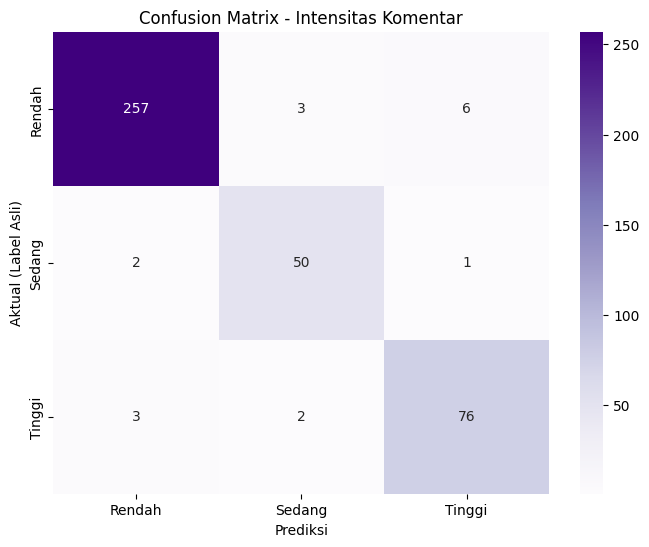


Report berhasil disimpan di ./model_indobert_intensitas/eval_intensity_report.txt


In [ ]:
print("\nMenghasilkan prediksi untuk data validasi...")
predictions = trainer.predict(val_dataset)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

target_names = ['Rendah', 'Sedang', 'Tinggi']

print("\n=== Classification Report Intensitas ===")
report = classification_report(y_true, y_pred, target_names=target_names)
print(report)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Prediksi')
plt.ylabel('Aktual (Label Asli)')
plt.title('Confusion Matrix - Intensitas Komentar')
plt.show()

with open(f"{save_directory}/eval_intensity_report.txt", "w") as f:
    f.write("=== Classification Report Intensitas ===\n")
    f.write(report)
    print(f"\nReport berhasil disimpan di {save_directory}/eval_intensity_report.txt")

# Aspek

In [ ]:
df = pd.read_excel('data_komentar_mbg_labeled.xlsx')
df = df.dropna(subset=['cleaned_comment', 'aspek'])
df['aspek_list'] = df['aspek'].apply(lambda x: [i.strip() for i in str(x).split(',')])

threshold = 100
aspek_counts = pd.Series([item for sublist in df['aspek_list'] for item in sublist]).value_counts()
rare_aspects = aspek_counts[aspek_counts < threshold].index.tolist()

print(f"Label langka yang akan di-oversample: {rare_aspects}")

oversampled_rows = []
for index, row in df.iterrows():
    if any(aspek in rare_aspects for aspek in row['aspek_list']):
        for _ in range(3):
            oversampled_rows.append(row)

df_oversampled = pd.concat([df, pd.DataFrame(oversampled_rows)], ignore_index=True)
print(f"Data setelah oversampling: {len(df_oversampled)} baris (Awal: {len(df)})")

mlb = MultiLabelBinarizer()
labels = mlb.fit_transform(df_oversampled['aspek_list'])

num_positives = labels.sum(axis=0)
num_negatives = len(labels) - num_positives
pos_weight = num_negatives / (num_positives + 1e-5)
pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float)

msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_index, val_index = next(msss.split(df_oversampled['cleaned_comment'], labels))

train_texts = df_oversampled.iloc[train_index]['cleaned_comment'].tolist()
train_labels = labels[train_index].astype(float)

val_texts = df_oversampled.iloc[val_index]['cleaned_comment'].tolist()
val_labels = labels[val_index].astype(float)

model_name = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_func(texts, labels):
    encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)
    return Dataset.from_dict({
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask'],
        'labels': labels
    })

train_ds = tokenize_func(train_texts, train_labels)
val_ds = tokenize_func(val_texts, val_labels)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=len(mlb.classes_), problem_type="multi_label_classification"
)

class WeightedMultilabelTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        device = logits.device
        loss_fct = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor.to(device))

        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.sigmoid(torch.Tensor(logits)).numpy()

    predictions = (probs > 0.4).astype(int)

    f1_macro = f1_score(labels, predictions, average='macro', zero_division=0)
    acc = accuracy_score(labels, predictions)
    return {'f1_macro': f1_macro, 'accuracy': acc}

training_args = TrainingArguments(
    output_dir='./results_aspek_oversampled',
    num_train_epochs=8,
    per_device_train_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    learning_rate=2e-5,
    weight_decay=0.01
)

trainer = WeightedMultilabelTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

trainer.train()

save_path = "./model_indobert_aspek_sentimen"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

with open(f"{save_path}/aspek_sentimen_classes.pkl", "wb") as f:
    pickle.dump(mlb.classes_, f)

print(f"Model berhasil disimpan di {save_path}")

Label langka yang akan di-oversample: ['Program:netral', 'Anggaran:positif', 'Pemerintahan:netral']
Data setelah oversampling: 2513 baris (Awal: 2000)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,No log,0.774402,0.407781,0.000000
2,No log,0.616686,0.523067,0.048924
3,No log,0.543905,0.598665,0.158513
4,0.621530,0.488824,0.647121,0.246575
5,0.621530,0.465599,0.700468,0.324853
6,0.621530,0.438113,0.726882,0.369863
7,0.621530,0.444448,0.740212,0.414873
8,0.238409,0.436146,0.753425,0.436399


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model berhasil disimpan di ./model_indobert_aspek_sentimen



Menghasilkan prediksi untuk data validasi...



--- Mencari Threshold Optimal per Kelas ---
Kelas [Anggaran:negatif] -> Best Threshold: 0.75 | F1: 0.87
Kelas [Anggaran:netral] -> Best Threshold: 0.40 | F1: 0.63
Kelas [Anggaran:positif] -> Best Threshold: 0.85 | F1: 0.97
Kelas [Distribusi:negatif] -> Best Threshold: 0.50 | F1: 0.76
Kelas [Distribusi:netral] -> Best Threshold: 0.65 | F1: 0.65
Kelas [Distribusi:positif] -> Best Threshold: 0.85 | F1: 0.72
Kelas [Kualitas Makanan:negatif] -> Best Threshold: 0.75 | F1: 0.77
Kelas [Kualitas Makanan:netral] -> Best Threshold: 0.70 | F1: 0.66
Kelas [Kualitas Makanan:positif] -> Best Threshold: 0.80 | F1: 0.83
Kelas [Pemerintahan:negatif] -> Best Threshold: 0.60 | F1: 0.90
Kelas [Pemerintahan:netral] -> Best Threshold: 0.85 | F1: 1.00
Kelas [Pemerintahan:positif] -> Best Threshold: 0.80 | F1: 0.92
Kelas [Program:negatif] -> Best Threshold: 0.70 | F1: 0.79
Kelas [Program:netral] -> Best Threshold: 0.80 | F1: 0.99
Kelas [Program:positif] -> Best Threshold: 0.65 | F1: 0.89

=== Classification R

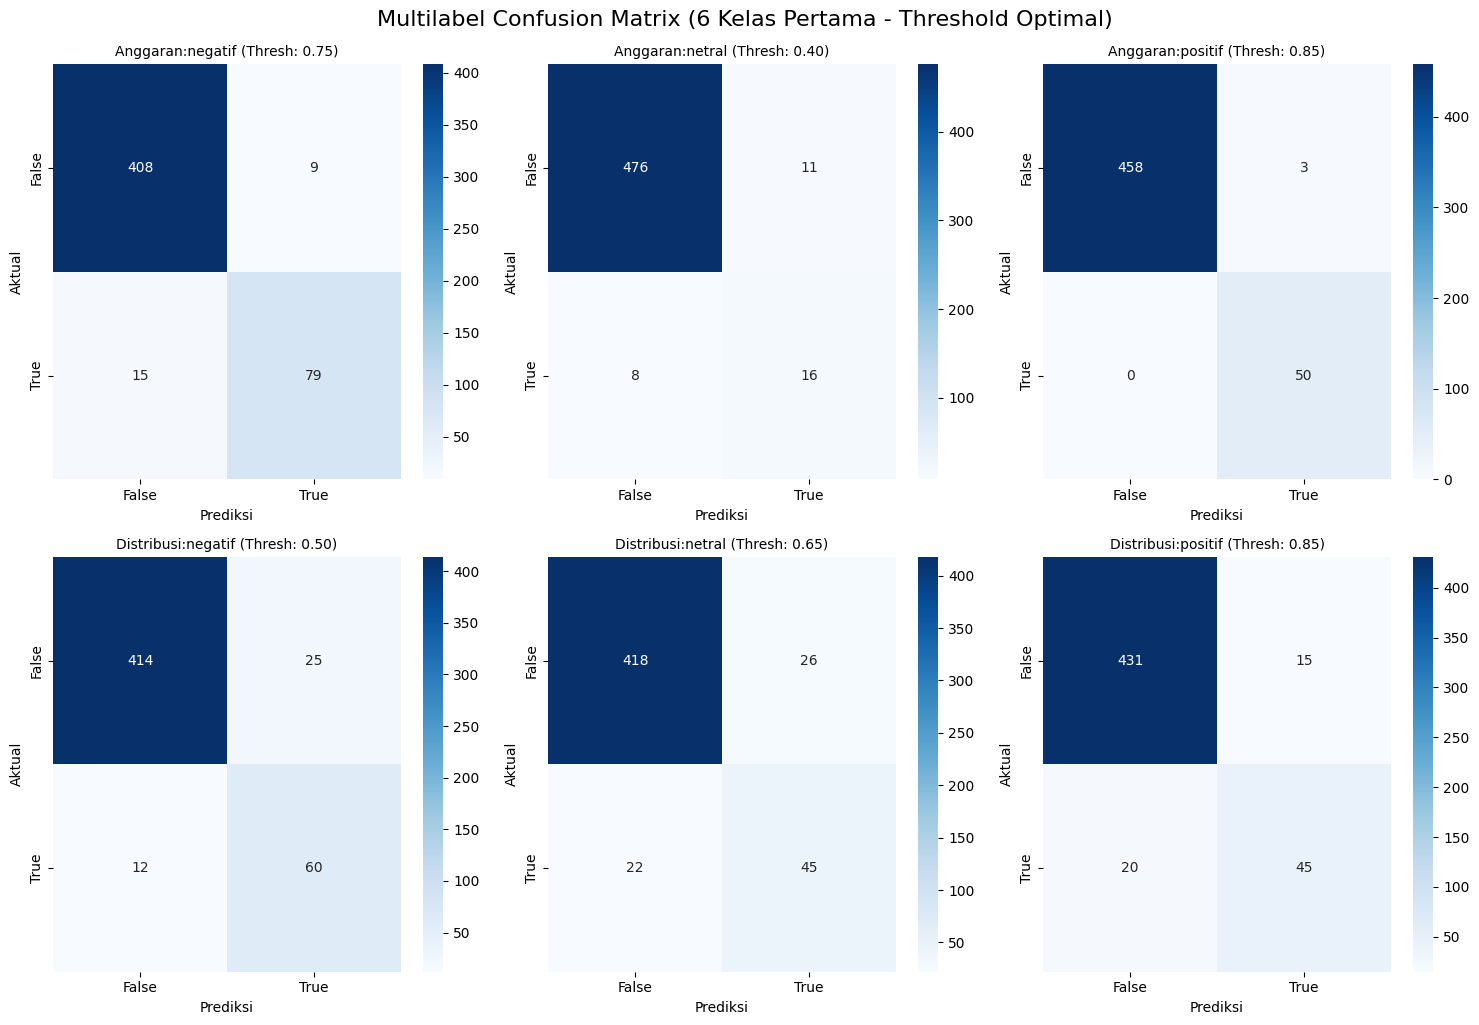

In [ ]:
print("\nMenghasilkan prediksi untuk data validasi...")
output = trainer.predict(val_ds)
logits = output.predictions
y_true = output.label_ids
probs = torch.sigmoid(torch.Tensor(logits)).numpy()
target_names = mlb.classes_

print("\n--- Mencari Threshold Optimal per Kelas ---")
best_thresholds = []
for i in range(len(target_names)):
    best_thresh = 0.5
    best_f1 = 0
    for thresh in np.arange(0.1, 0.9, 0.05):
        preds = (probs[:, i] > thresh).astype(int)
        score = f1_score(y_true[:, i], preds, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_thresh = thresh
    best_thresholds.append(best_thresh)
    print(f"Kelas [{target_names[i]}] -> Best Threshold: {best_thresh:.2f} | F1: {best_f1:.2f}")

with open(f"{save_path}/best_thresholds.json", "w") as f:
    json.dump({target_names[i]: float(best_thresholds[i]) for i in range(len(target_names))}, f)

y_pred_opt = np.zeros_like(probs)
for i in range(len(target_names)):
    y_pred_opt[:, i] = (probs[:, i] > best_thresholds[i]).astype(int)

print("\n=== Classification Report Aspek:Sentimen (Multi-label) ===")
print(classification_report(y_true, y_pred_opt, target_names=target_names, zero_division=0))

mcm = multilabel_confusion_matrix(y_true, y_pred_opt)

num_classes_to_show = min(len(target_names), 6)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i in range(num_classes_to_show):
    sns.heatmap(mcm[i], annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['False', 'True'],
                yticklabels=['False', 'True'])
    axes[i].set_title(f'{target_names[i]} (Thresh: {best_thresholds[i]:.2f})', fontsize=10)
    axes[i].set_xlabel('Prediksi')
    axes[i].set_ylabel('Aktual')

plt.tight_layout()
plt.suptitle('Multilabel Confusion Matrix (6 Kelas Pertama - Threshold Optimal)', y=1.02, fontsize=16)
plt.show()

with open(f"{save_path}/eval_aspek_sentimen_report.txt", "w") as f:
    f.write("=== Classification Report Aspek:Sentimen (Threshold Optimal) ===\n")
    f.write(classification_report(y_true, y_pred_opt, target_names=target_names, zero_division=0))

# Inferences

In [ ]:
input_file = "data_komentar_mbg.xlsx"
output_file = "data_komentar_mbg_prediction.xlsx"

model_paths = {
    'sentimen': './model_indobert_sentimen_global',
    'emosi': './model_indobert_emosi',
    'intensitas': './model_indobert_intensitas',
    'aspek': './model_indobert_aspek_sentimen'
}

def load_model_tools(path):
    print(f"Loading model dari: {path}...")
    tokenizer = AutoTokenizer.from_pretrained(path)
    model = AutoModelForSequenceClassification.from_pretrained(path)
    model.eval()
    if torch.cuda.is_available():
        model.to('cuda')
    return tokenizer, model

tools = {k: load_model_tools(v) for k, v in model_paths.items()}

with open(f"{model_paths['aspek']}/aspek_sentimen_classes.pkl", "rb") as f:
    aspek_classes = pickle.load(f)

try:
    with open(f"{model_paths['aspek']}/best_thresholds.json", "r") as f:
        best_thresholds_dict = json.load(f)
    print("Berhasil memuat threshold optimal!")
except FileNotFoundError:
    print("Warning: best_thresholds.json tidak ditemukan. Menggunakan default 0.4")
    best_thresholds_dict = {kelas: 0.4 for kelas in aspek_classes}

best_thresholds = np.array([best_thresholds_dict.get(kelas, 0.4) for kelas in aspek_classes])

aspect_groups = {}
for i, cls_name in enumerate(aspek_classes):
    base_aspect = cls_name.split(':')[0]
    if base_aspect not in aspect_groups:
        aspect_groups[base_aspect] = []
    aspect_groups[base_aspect].append(i)

def predict_all(text):
    text = str(text).strip()
    if not text or text.lower() == 'nan':
        return 'netral', 'Netral', 'Rendah', 'Program:netral'

    inputs = {k: t[0](text, return_tensors="pt", truncation=True, padding=True, max_length=128)
              for k, t in tools.items()}

    if torch.cuda.is_available():
        for k in inputs:
            inputs[k] = {nk: nv.to('cuda') for nk, nv in inputs[k].items()}

    with torch.no_grad():
        out_sent = tools['sentimen'][1](**inputs['sentimen'])
        idx_sent = torch.argmax(out_sent.logits, dim=-1).item()
        # Fix: Define res_sent based on idx_sent
        res_sent = ['negatif', 'netral', 'positif'][idx_sent]

        out_emo = tools['emosi'][1](**inputs['emosi'])
        idx_emo = torch.argmax(out_emo.logits, dim=-1).item()
        res_emo = ['Marah', 'Senang', 'Cemas', 'Netral'][idx_emo]

        out_int = tools['intensitas'][1](**inputs['intensitas'])
        idx_int = torch.argmax(out_int.logits, dim=-1).item()
        res_int = ['Rendah', 'Sedang', 'Tinggi'][idx_int]

        out_asp = tools['aspek'][1](**inputs['aspek'])
        probs_asp = torch.sigmoid(out_asp.logits).cpu().numpy()[0]

        res_asp_list = []

        for aspect_name, indices in aspect_groups.items():
            group_probs = probs_asp[indices]
            local_max_idx = np.argmax(group_probs)
            global_idx = indices[local_max_idx]
            max_prob = group_probs[local_max_idx]
            target_threshold = best_thresholds[global_idx]

            if max_prob > target_threshold:
                res_asp_list.append(aspek_classes[global_idx])
        res_asp = ", ".join(res_asp_list) if res_asp_list else "Program:netral"

    return res_sent, res_emo, res_int, res_asp

print(f"Membaca file: {input_file}")
df = pd.read_excel(input_file)
column_to_process = 'comment'

tqdm.pandas()
print(f"Memulai proses inference untuk {len(df)} data...")

results = df[column_to_process].progress_apply(predict_all)

df[['sentimen_global', 'emosi', 'intensitas', 'aspek_sentimen']] = pd.DataFrame(results.tolist(), index=df.index)

df.to_excel(output_file, index=False)
print(f"\nSelesai! Hasil disimpan di '{output_file}'")

Loading model dari: ./model_indobert_sentimen_global...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading model dari: ./model_indobert_emosi...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading model dari: ./model_indobert_intensitas...


...

Loading model dari: ./model_indobert_aspek_sentimen...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Berhasil memuat threshold optimal!
Membaca file: data_komentar_mbg.xlsx
Memulai proses inference untuk 10653 data...


100%|██████████| 10653/10653 [06:49<00:00, 26.02it/s]



Selesai! Hasil disimpan di 'data_komentar_mbg_prediction.xlsx'


# Visualisasi

/tmp/ipykernel_4932/1655323911.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentimen_global', palette='viridis', ax=ax1,
/tmp/ipykernel_4932/1655323911.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='emosi', palette='magma', ax=ax2,
/tmp/ipykernel_4932/1655323911.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='intensitas', palette='rocket', ax=ax3,
/tmp/ipykernel_4932/1655323911.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0

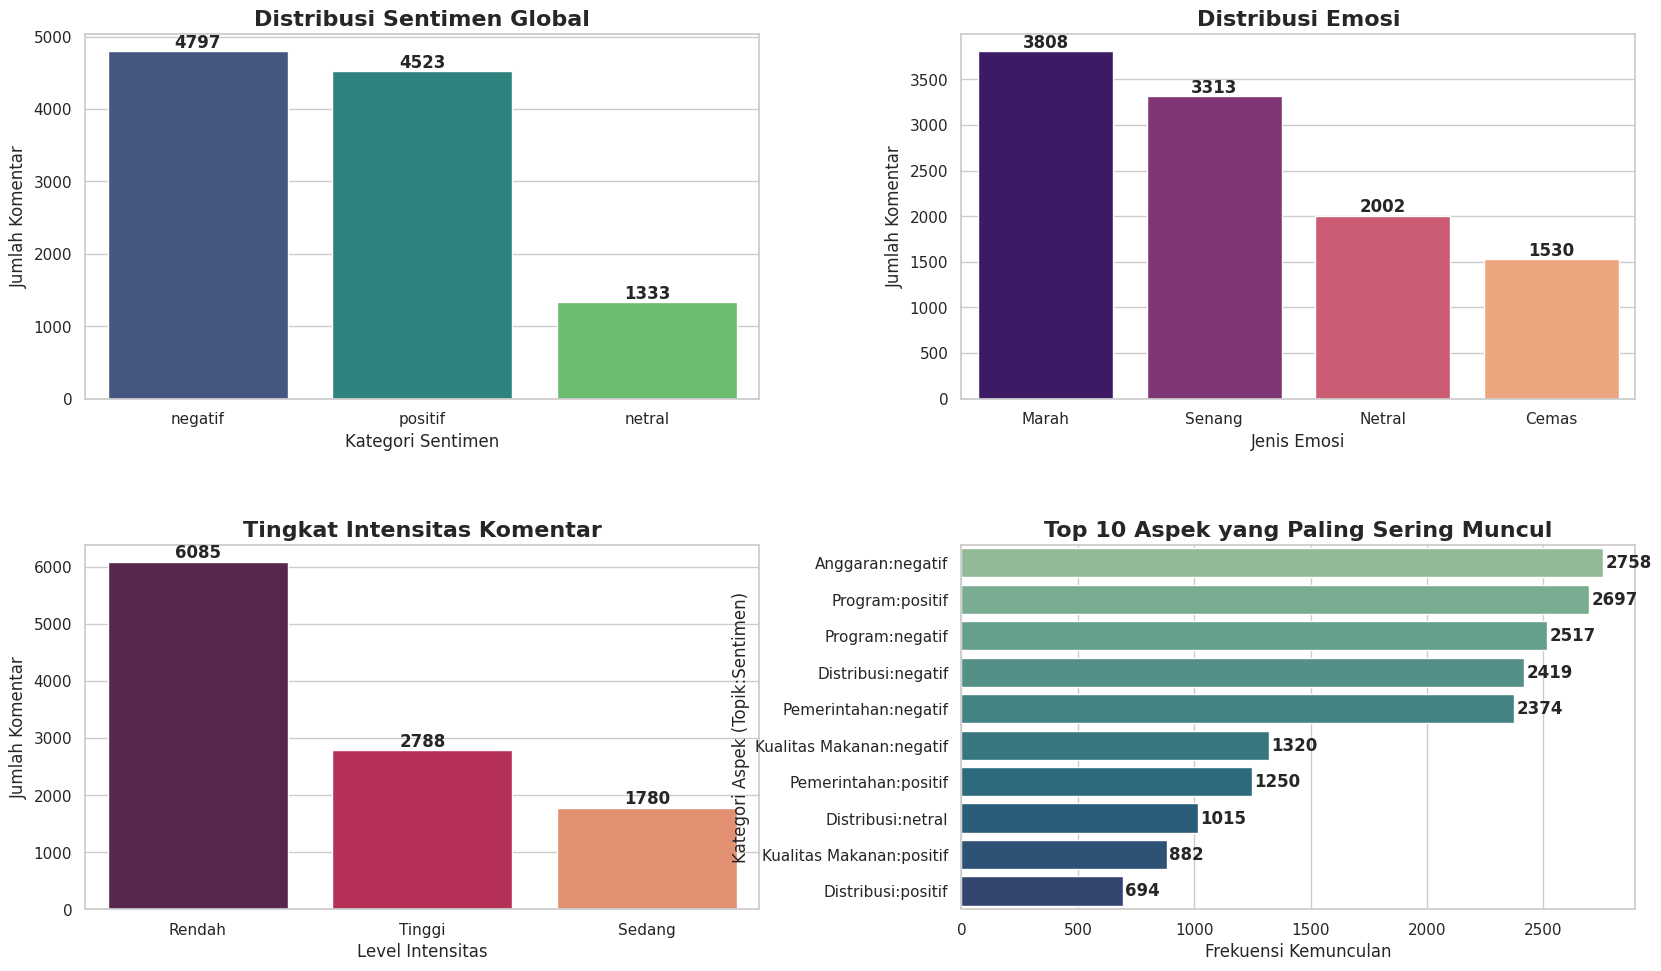

In [ ]:
sns.set_theme(style="whitegrid")
file_name = 'data_komentar_mbg_prediction.xlsx'

df = pd.read_excel(file_name)
df_aspek = df['aspek_sentimen'].str.split(',').explode().str.strip()
top_10_aspek = df_aspek.value_counts().head(10)

fig = plt.figure(figsize=(20, 18))
gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
sns.countplot(data=df, x='sentimen_global', palette='viridis', ax=ax1,
              order=df['sentimen_global'].value_counts().index)
ax1.set_title('Distribusi Sentimen Global', fontsize=16, fontweight='bold')
ax1.set_xlabel('Kategori Sentimen')
ax1.set_ylabel('Jumlah Komentar')
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom', fontweight='bold')

ax2 = fig.add_subplot(gs[0, 1])
sns.countplot(data=df, x='emosi', palette='magma', ax=ax2,
              order=df['emosi'].value_counts().index)
ax2.set_title('Distribusi Emosi', fontsize=16, fontweight='bold')
ax2.set_xlabel('Jenis Emosi')
ax2.set_ylabel('Jumlah Komentar')
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom', fontweight='bold')

ax3 = fig.add_subplot(gs[1, 0])
sns.countplot(data=df, x='intensitas', palette='rocket', ax=ax3,
              order=df['intensitas'].value_counts().index)
ax3.set_title('Tingkat Intensitas Komentar', fontsize=16, fontweight='bold')
ax3.set_xlabel('Level Intensitas')
ax3.set_ylabel('Jumlah Komentar')
for p in ax3.patches:
    ax3.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom', fontweight='bold')

ax4 = fig.add_subplot(gs[1, 1])
sns.barplot(x=top_10_aspek.values, y=top_10_aspek.index, palette='crest', ax=ax4)
ax4.set_title('Top 10 Aspek yang Paling Sering Muncul', fontsize=16, fontweight='bold')
ax4.set_xlabel('Frekuensi Kemunculan')
ax4.set_ylabel('Kategori Aspek (Topik:Sentimen)')
for i, v in enumerate(top_10_aspek.values):
    ax4.text(v + 10, i, str(int(v)), va='center', fontweight='bold')
